# Helios 03 — Analytical Core: terrain, COGs, STAC, and solar scoring

**Solar site-selection, step 3: the analytical layer.** Roof solar yield depends on
**slope** and **aspect** (south-facing, gently sloped wins). This notebook stages a
**USGS 3DEP** DEM for San Francisco, converts it to **Cloud-Optimized GeoTIFFs** with
`gbx_rst_cog_convert`, **catalogs the COGs into a queryable Delta table** — a
time-travel-friendly catalog of the analysis-ready elevation assets — derives
slope/aspect/hillshade, aggregates them into a per-**H3-cell** `solar_score` index
(composing with Databricks-native H3), and renders the hillshade as PMTiles.

> GeoBrix tiling and raster→grid aggregation are an on-ramp into Databricks-native
> spatial: the H3 `cellid` we produce is a standard native id you can join and render
> with native H3 functions.

> Runs on the **lightweight tier (Serverless)** by default.

---
_Last Modified:_ June 29, 2026


![3DEP DEM to COG + STAC + hillshade PMTiles](https://raw.githubusercontent.com/databrickslabs/geobrix/main/resources/images/diagrams/helios/helios-03.png)

In [0]:
%run ./config_nb

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


... skipping spark.conf.set(spark.sql.adaptive.coalescePartitions.enabled) [Serverless?]: AnalysisException


True

... catalog: 'geospatial_docs' (USE)
... schema: 'geobrix' (CREATE / USE)


... ETL_DIR: '/Volumes/geospatial_docs/geobrix/data'
... HELIOS_DIR: '/Volumes/geospatial_docs/geobrix/data/helios' (MKDIRS)
... SF_CITY_BBOX: (-122.52, 37.7, -122.35, 37.83)


In [0]:
# Toggles (also overridable per-notebook in a cell right after %run ./config_nb):
FORCE_REBUILD = False      # True (default False) -> re-create tables / re-download / re-tile (skip-guards off)
INTERACTIVE_PLOTS = False  # False (default) -> fast static maps that render on GitHub; True -> interactive maps

## 1. Stage a USGS 3DEP DEM (`DemDownloader`)

USGS 3DEP elevation is STAC on Planetary Computer (collection `3dep-seamless`). We
dogfood the product **`DemDownloader`** (a thin `gbx.sample` wrapper over `StacClient`):
`download_dem_aoi` searches the collection, selects the **finest** resolution tier
(10 m over 30 m), and **windows each tile to the AOI on read** (`bbox` + `bbox_crs`),
fanning the download across tiles in parallel. The result is the real 3DEP GeoTIFF(s) in
`DEM_DIR` covering the city — correct georeferencing handled in-product, no hand-rolled
`pystac`/`rasterio` windowing glue.

... staged 1 3DEP DEM tile(s) -> /Volumes/geospatial_docs/geobrix/data/helios/dem


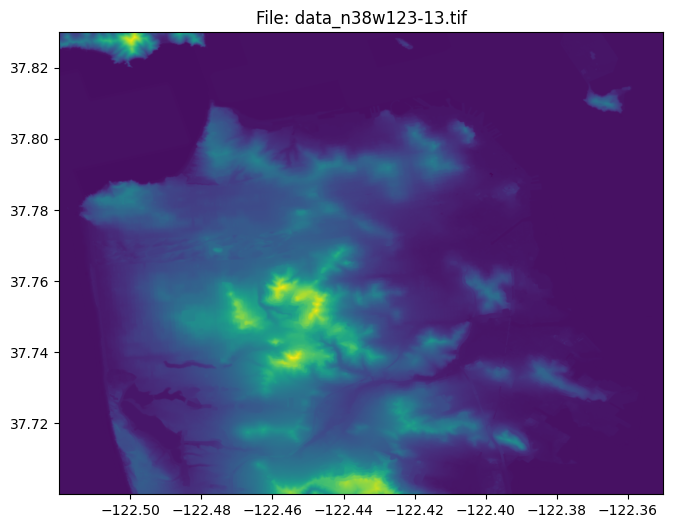

In [0]:
import glob
import os

from databricks.labs.gbx.sample import download_dem_aoi

DEM_DIR = f"{HELIOS_DIR}/dem"
os.makedirs(DEM_DIR, exist_ok=True)   # Volume FUSE-safe; idempotent

# Skip-guard: reuse already-staged DEM tif(s) unless FORCE_REBUILD.
_existing = sorted(glob.glob(f"{DEM_DIR}/*.tif"))
if _existing and not FORCE_REBUILD:
    DEM_PATHS = _existing
    print(f"... DEM already staged ({len(DEM_PATHS)} tile(s)) in {DEM_DIR}")
else:
    for _p in _existing:      # clear stale tiles so a changed AOI can't leave orphans
        os.remove(_p)
    # Product DemDownloader (one-shot): search 3dep-seamless, pick the FINEST gsd tier
    # (10 m over 30 m), and window each tile to the AOI on read (bbox + bbox_crs), fanning
    # the download across tiles in parallel — no hand-rolled pystac/rasterio windowing.
    staged_df = download_dem_aoi(
        spark, list(SF_CITY_BBOX), DEM_DIR,
        resolution="finest", bbox_crs="EPSG:4326",
    )
    DEM_PATHS = sorted(
        r["out_file_path"] for r in staged_df.collect()
        if r["is_out_file_valid"] and r["out_file_path"]
    )
    print(f"... staged {len(DEM_PATHS)} 3DEP DEM tile(s) -> {DEM_DIR}")

DEM_PATH = DEM_PATHS[0]   # representative tile for the preview below
plot_file(DEM_PATH, fig_w=8, fig_h=6)

## 2. Convert the DEM to Cloud-Optimized GeoTIFF

`gbx_rst_cog_convert` rewrites the raster as a COG (internal tiling + overviews) so
downstream tools can do fast windowed and overview reads. We load the DEM(s) with the
light **`gtiff_gbx`** reader — it builds the typed tile struct directly (no hand-rolled
`binaryFile` + `rst_fromcontent`) — convert, and write the COG(s) back with the matching
**`gtiff_gbx`** writer. Read and write are the same GTiff tile family, so the pipeline is
symmetric and scales across every source DEM (one COG per source) with FUSE-safe
per-executor writes.

In [0]:
# Load the DEM(s) with the light gtiff_gbx reader -> (source, tile). The reader builds
# the typed tile struct directly — no hand-rolled binaryFile + rst_fromcontent.
# Fan out by SOURCE raster: repartition by `source` so cog_convert + slope/aspect/
# hillshade + H3 binning + the XYZ pyramid all run in parallel across sources. A column
# key is required — number-only repartition(N) is AQE-coalesced to serial on Serverless.
# The demo stages one DEM (one partition); point DEM_DIR at many tiles and it fans out.
dem = (
    spark.read.format("gtiff_gbx")
         .option("filterRegex", r".*\.tif$")
         .load(DEM_DIR)
         .repartition(64, F.col("source"))
)

# Convert to COG layout (DEFLATE compression, 512-px blocks, AVERAGE overviews) and
# shape to the gtiff_gbx writer's exact (source, tile) schema. `source` is the output
# basename, from the reader's source path.
# gbx_rst_cog_convert signature: rst_cog_convert(tile [, compression [, blocksize [, overview_resampling]]])
cog = dem.select(
    F.regexp_extract(F.col("source"), r"([^/]+?)(?:\.[^./]+)?$", 1).alias("source"),
    rx.rst_cog_convert("tile").alias("tile"),
)

# Write the COG(s) to the Volume with the product gtiff_gbx writer (light-tier
# DataSource, registered in config_nb) — read and write are the same GTiff tile family.
# GTiff bytes pass through verbatim; one row per source -> one <source>.tif in COG_DIR.
# Scales across every source DEM with FUSE-safe per-executor writes.
COG_DIR = f"{HELIOS_DIR}/cog"
os.makedirs(COG_DIR, exist_ok=True)   # Volume root pre-exists; create the cog subdir
if FORCE_REBUILD or not glob.glob(f"{COG_DIR}/*.tif"):
    (
        cog.write.format("gtiff_gbx")
           .option("nameCol", "source")
           .mode("overwrite")
           .save(COG_DIR)
    )

COG_PATHS = sorted(glob.glob(f"{COG_DIR}/*.tif"))
COG_PATH = COG_PATHS[0]   # representative COG for the §3 inline inspection
print(f"... {len(COG_PATHS)} COG(s) in {COG_DIR}")

... 1 COG(s) in /Volumes/geospatial_docs/geobrix/data/helios/cog


## 3. View the COG

`show_cog` (from `config_nb`) does a rasterio overview read and renders the elevation
surface with a contextily basemap.

<Axes: title={'center': 'COG'}>

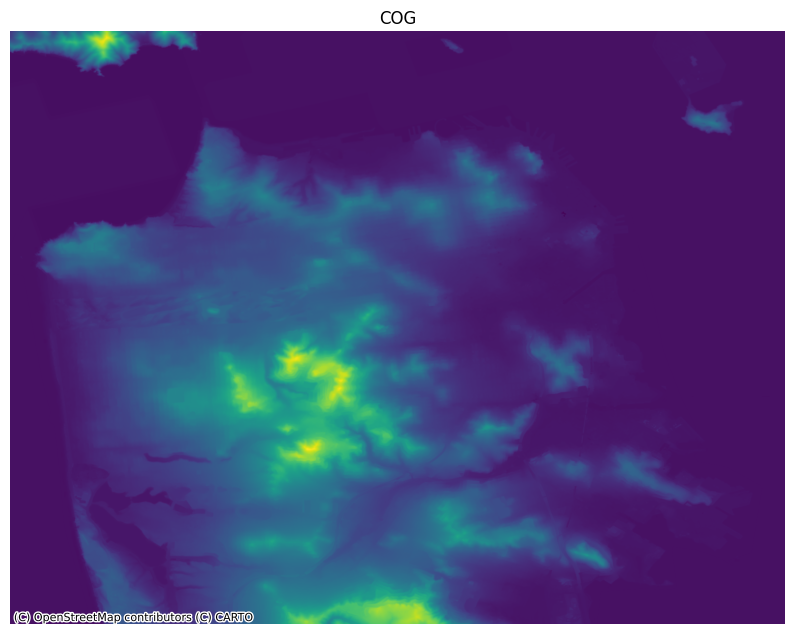

In [0]:
show_cog(COG_PATH)

## 4. Catalog the COGs into a Delta table

We register the COG(s) as items in a queryable Delta table — a re-runnable,
time-travel-friendly catalog of the analysis-ready elevation assets, keyed by their
Volume path. We build it by reading the staged COGs back with the light **`raster_gbx`**
reader and deriving each asset's footprint and CRS with product accessors —
**`gbx_rst_boundingbox`** (a bounds polygon as WKB, in the raster's native CRS) and
**`gbx_rst_srid`** (the EPSG code) — instead of a hand-rolled driver-side
`rasterio.open`. Distributed and scalable across many COGs; materialized with
`finalize_delta`.

In [0]:
# Catalog the staged COGs with product raster accessors instead of driver-side rasterio:
# read them back with the light raster_gbx reader, then derive each asset's footprint and
# CRS in-Spark — gbx_rst_boundingbox (bounds as WKB BINARY, in the raster's native CRS)
# and gbx_rst_srid (the EPSG code). Keyed by the COG's Volume path (raster_gbx's `source`
# column). Distributed + scales across many COGs; no hand-rolled rasterio.open.
cog_catalog = (
    spark.read.format("raster_gbx").option("filterRegex", r".*\.tif$").load(COG_DIR)
    .select(
        F.regexp_extract(F.col("source"), r"([^/]+?)(?:\.[^./]+)?$", 1).alias("item_id"),
        F.col("source"),
        rx.rst_srid("tile").alias("srid"),
        rx.rst_boundingbox("tile").alias("bbox_wkb"),
        F.lit("3dep-seamless").alias("collection"),
    )
)
sf_cog_catalog = finalize_delta(cog_catalog, "sf_cog_catalog")

# bbox_wkb is WKB BINARY (native CRS). Parse it to a native GEOMETRY with st_geomfromwkb,
# then st_astext for a readable footprint — the GeoBrix bbox flows straight into
# Databricks-native ST (compose with st_intersects, etc. for spatial catalog queries).
# display(sf_cog_catalog.selectExpr(
#     "item_id", "source", "srid", "st_astext(st_geomfromwkb(bbox_wkb)) AS bbox", "collection"
# ))
sf_cog_catalog.selectExpr(
    "item_id", "source", "srid", "st_astext(st_geomfromwkb(bbox_wkb)) AS bbox", "collection"
).limit(1).show(vertical=True) # <- for ipynb in GitHub

... wrote table sf_cog_catalog (1 rows)
root
 |-- item_id: string (nullable = true)
 |-- source: string (nullable = true)
 |-- srid: integer (nullable = true)
 |-- bbox_wkb: binary (nullable = true)
 |-- collection: string (nullable = true)

-RECORD 0--------------------------
 item_id    | data_n38w123-13      
 source     | dbfs:/Volumes/geo... 
 srid       | 4269                 
 bbox       | POLYGON((-122.349... 
 collection | 3dep-seamless        



## 5. Derive slope, aspect, hillshade, and a solar score

Slope and aspect come straight from the DEM tile.

Registered names (confirmed against `registered_functions.txt`):
- `gbx_rst_slope` / `rx.rst_slope` — slope in degrees, auto-scaled from CRS (no manual `-s`).
- `gbx_rst_aspect` / `rx.rst_aspect` — aspect in degrees, GDAL convention (0=N, 90=E, 180=S, 270=W).
- `gbx_rst_hillshade` / `rx.rst_hillshade` — relief shading at default azimuth/altitude.

`solar_score` (defined in `config_nb`) favors gently sloped, south-facing terrain. It is
applied per H3 cell in step 5b, where slope and aspect are aggregated onto the H3 grid.

In [0]:
# gbx_rst_slope / gbx_rst_aspect / gbx_rst_hillshade: tile-in, tile-out.
# Slope/hillshade auto-scale from CRS per GDAL 3.11 formula — no manual scale arg.
# Aspect is scale-invariant.
# Fans out per source (the load cell repartitioned by `path`). NOTE: with MANY
# adjacent source DEMs, slope/hillshade are computed independently per source, so
# gradients can seam at shared edges — mosaic first, or split with overlapping
# source tiles + trim, for seamless terrain across a large area.
terrain = cog.select(
    rx.rst_slope("tile").alias("slope_tile"),
    rx.rst_aspect("tile").alias("aspect_tile"),
    rx.rst_hillshade("tile").alias("hillshade_tile"),
)
sf_terrain = finalize_delta(terrain, "sf_terrain", do_display=True)
print("... slope / aspect / hillshade tiles materialized")

... wrote table sf_terrain (1 rows)
root
 |-- slope_tile: struct (nullable = true)
 |    |-- cellid: long (nullable = true)
 |    |-- raster: binary (nullable = true)
 |    |-- metadata: map (nullable = true)
 |    |    |-- key: string
 |    |    |-- value: string (valueContainsNull = true)
 |-- aspect_tile: struct (nullable = true)
 |    |-- cellid: long (nullable = true)
 |    |-- raster: binary (nullable = true)
 |    |-- metadata: map (nullable = true)
 |    |    |-- key: string
 |    |    |-- value: string (valueContainsNull = true)
 |-- hillshade_tile: struct (nullable = true)
 |    |-- cellid: long (nullable = true)
 |    |-- raster: binary (nullable = true)
 |    |-- metadata: map (nullable = true)
 |    |    |-- key: string
 |    |    |-- value: string (valueContainsNull = true)

... slope / aspect / hillshade tiles materialized


## 5b. Aggregate slope + aspect into a per-H3-cell solar-suitability index

GeoBrix raster→grid aggregation bins the slope and aspect rasters onto **H3 cells**
(`gbx_rst_h3_rastertogridavg`), emitting a standard H3 integer `cellid` per cell.

Function contract (confirmed against light-tier UDTF registration and tests):
- Signature: `gbx_rst_h3_rastertogridavg(tile, resolution)` — **UDTF** invoked via
  SQL `LATERAL`. Each output row is `(band INT, cellID LONG, measure DOUBLE)`.
- Use `LATERAL gbx_rst_h3_rastertogridavg(tile, resolution) t` and filter
  `WHERE t.band = 1` to select band 1. No `[0]` indexing or `LATERAL VIEW explode`.
- **Expects EPSG:4326 lon/lat.** SRTM is already 4326; 3DEP may be EPSG:4269 (NAD83).
  The code calls `rx.rst_transform(tile, F.lit(4326))` on the slope/aspect tiles before
  aggregation — this is a no-op when the CRS is already 4326 and corrects NAD83 3DEP
  (cm-scale offset at SF, but correct by contract).

Because that `cellid` is a native H3 id, the result composes directly with
**Databricks-native H3** functions — `h3_centeraswkb` / `h3_boundaryaswkb` for cell
geometry, `h3_hexring` for neighborhoods. We gate the native-H3 geometry step behind a
capability check: `h3_centeraswkb` requires Photon or Databricks SQL, which may not be
available in all environments (e.g., Docker or local Spark).


In [0]:
H3_RES = 9   # H3 resolution 9 (~175 m cells) — appropriate for a city-scale DEM.

# Register the pre-derived terrain tiles as a temp view for SQL access.
# sf_terrain has columns: slope_tile, aspect_tile, hillshade_tile.
sf_terrain.createOrReplaceTempView("sf_terrain_tiles")

# gbx_rst_h3_rastertogridavg is a light-tier UDTF invoked via SQL LATERAL.
# Each output row: band INT (1-based), cellID LONG (H3 integer id), measure DOUBLE.
# Filter WHERE t.band = 1 to select the first (and only) band.
# No [0] indexing or LATERAL VIEW explode — those are the heavy-tier pattern.
#
# rst_transform(tile, 4326) normalises CRS to EPSG:4326 before aggregation.
# SRTM is already 4326 (no-op); 3DEP may be EPSG:4269 (NAD83) — corrected here.
slope_cells = spark.sql(f"""
    SELECT t.cellID AS cellid, t.measure AS avg_slope
    FROM sf_terrain_tiles,
         LATERAL gbx_rst_h3_rastertogridavg(gbx_rst_transform(slope_tile, 4326), {H3_RES}) t
    WHERE t.band = 1
""")

aspect_cells = spark.sql(f"""
    SELECT t.cellID AS cellid, t.measure AS avg_aspect
    FROM sf_terrain_tiles,
         LATERAL gbx_rst_h3_rastertogridavg(gbx_rst_transform(aspect_tile, 4326), {H3_RES}) t
    WHERE t.band = 1
""")

# Inner join on shared H3 cell ids (both rasters cover the same AOI).
cells = slope_cells.join(aspect_cells, on="cellid", how="inner")

# Apply solar_score per cell (from config_nb).
# solar_score(slope_col, aspect_col) expects column NAME strings (not Column objects).
scored = cells.select(
    "cellid",
    "avg_slope",
    "avg_aspect",
    solar_score(slope_col="avg_slope", aspect_col="avg_aspect").alias("solar_score"),
)

# Native H3: h3_centeraswkb requires Photon / Databricks SQL — gate behind try/skip
# so the rest of the notebook stays green where native H3 is absent (e.g., Docker).
_native_h3_ok = False
try:
    scored.selectExpr("h3_centeraswkb(cellid) AS _test").limit(1).collect()
    _native_h3_ok = True
except Exception as _e:
    print(f"... native h3_centeraswkb not available ({type(_e).__name__}); "
          "skipping cell_center_wkb column (requires Photon / Databricks SQL)")

if _native_h3_ok:
    # h3_centeraswkb(cellid BIGINT) -> BINARY (WKB Point at H3 cell center).
    # Confirmed Databricks-native H3 built-in (companions: h3_boundaryaswkb, h3_hexring).
    scored = scored.selectExpr(
        "*",
        "h3_centeraswkb(cellid) AS cell_center_wkb",
    )
    print("... native h3_centeraswkb available — cell_center_wkb column added")

sf_solar_cells = finalize_delta(scored, "sf_solar_cells")
# display(sf_solar_cells.orderBy(F.col("solar_score").desc()).limit(10))
sf_solar_cells.orderBy(F.col("solar_score").desc()).limit(1).show(vertical=True) # <- for ipynb in GitHub

... native h3_centeraswkb available — cell_center_wkb column added
... wrote table sf_solar_cells (1,680 rows)
root
 |-- cellid: long (nullable = true)
 |-- avg_slope: double (nullable = true)
 |-- avg_aspect: double (nullable = true)
 |-- solar_score: double (nullable = true)
 |-- cell_center_wkb: binary (nullable = true)

-RECORD 0-------------------------------
 cellid          | 617700171187224575   
 avg_slope       | 26.39915013574026    
 avg_aspect      | 170.257777752008     
 solar_score     | 0.9530685637418214   
 cell_center_wkb | [01 01 00 00 00 8... 



## 6. Tile the hillshade to raster PMTiles

Reproject the hillshade to web mercator, slice it into an XYZ pyramid with the
light-tier `gbx_rst_xyzpyramid` UDTF, and fold it into PMTiles with `gbx_pmtiles_agg`.
The hillshade is a single in-memory raster (not a directory of quads), so the
`rst_xyzpyramid` UDTF is the right tool here — one source tile → one non-overlapping
pyramid → no tiles lost, and raster PMTiles resolve first-wins per `(z, x, y)`.

The UDTF's flat output columns — `z INTEGER, x INTEGER, y INTEGER, bytes BINARY` — feed
straight into `gbx_pmtiles_agg`, so the pyramid flows into the archive in one aggregation.

_Turned off `INTERACTIVE_PLOTS` for GitHub/docs rendering of ipynb export._

In [0]:
# Reproject hillshade tile to web mercator (EPSG:3857) — required for the XYZ grid.
hs_3857 = sf_terrain.select(rx.rst_to_webmercator("hillshade_tile").alias("tile"))
hs_3857.createOrReplaceTempView("sf_hillshade_tile")

# gbx_rst_xyzpyramid (light-tier UDTF) signature:
#   gbx_rst_xyzpyramid(tile, min_z, max_z [, format [, size [, resampling]]])
# Output columns (flat, light tier): z INTEGER, x INTEGER, y INTEGER, bytes BINARY
# Use LATERAL (not LATERAL VIEW) — the UDTF emits rows directly (no explode needed).
hs_xyz = spark.sql("""
    SELECT t.z, t.x, t.y, t.bytes AS png
    FROM sf_hillshade_tile,
         LATERAL gbx_rst_xyzpyramid(tile, 11, 14) t
""")

sf_hs_xyz = finalize_delta(hs_xyz, "sf_hillshade_xyz_tiles")
print(f"... {sf_hs_xyz.count():,} (z,x,y) hillshade tiles across z11-z14")

# Fold into PMTiles with the gbx_pmtiles_agg aggregator (grayscale PNG tiles pass
# through verbatim — the encoding the interactive viewer renders). First-wins for
# raster; one source tile means no overlapping (z,x,y) to resolve.
# gbx_pmtiles_agg signature: gbx_pmtiles_agg(bytes, z, x, y [, metadata_json])
archive_row = (
    sf_hs_xyz.groupBy(F.lit(1).alias("_g"))
             .agg(F.expr("gbx_pmtiles_agg(png, z, x, y)").alias("archive"))
             .select("archive")
             .collect()[0]
)
TILES_DIR = f"{HELIOS_DIR}/tiles"
os.makedirs(TILES_DIR, exist_ok=True)   # Volume FUSE-safe; idempotent
HS_PMTILES = f"{TILES_DIR}/sf_hillshade.pmtiles"
with open(HS_PMTILES, "wb") as f:
    f.write(archive_row["archive"])
print(f"... wrote {HS_PMTILES} ({os.path.getsize(HS_PMTILES):,} bytes)")

... wrote table sf_hillshade_xyz_tiles (119 rows)
root
 |-- z: integer (nullable = true)
 |-- x: integer (nullable = true)
 |-- y: integer (nullable = true)
 |-- png: binary (nullable = true)

... 119 (z,x,y) hillshade tiles across z11-z14
... wrote /Volumes/geospatial_docs/geobrix/data/helios/tiles/sf_hillshade.pmtiles (1,842,169 bytes)


... pmtiles: type=png zoom=11-14 bounds=(-122.6953125, 37.5794125, -122.34375, 37.8575072)
[vizx] layer[0] 0.0MB = 2.3MB > 0MB → static fallback


<Axes: >

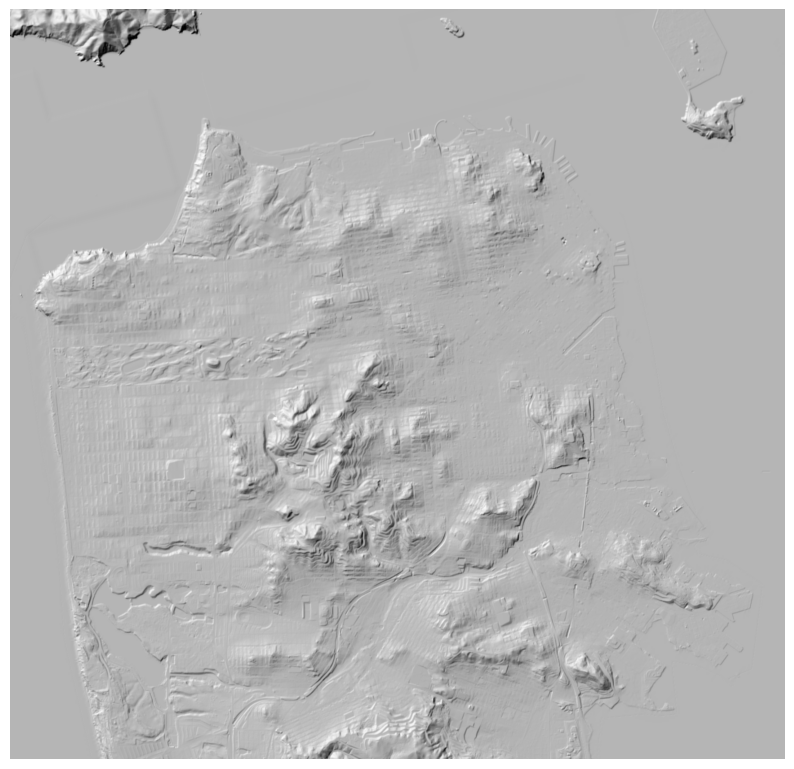

In [0]:
# Render the hillshade PMTiles inline. show_pmtiles frames the map on the archive's
# bounds (the pyramid's web-mercator tile grid) and honors INTERACTIVE_PLOTS: an
# interactive MapLibre map when True, a static image for GitHub/docs when False.
show_pmtiles(HS_PMTILES)

## 7. Overlay: hillshade + building footprints + solar score

When `INTERACTIVE_PLOTS = True`, `plot_interactive` stacks three layers to make the
analysis pop: the **hillshade** PMTiles as a muted relief *underlay*, the per-**H3-cell**
**solar score** colored *per cell* by `solar_score` through a vivid `RdYlGn` ramp
(green = most suitable) and rendered semi-transparent over it, and the NB01 **building
footprints** as thin dark *outlines* on top — so you can read which roofs fall in the
high-scoring cells without masking the heatmap. A colormap **legend** shows the score
range. `emphasis="blend"` keeps a soft composite and the view opens framed on the AOI.
Each layer degrades gracefully when its upstream archive or table isn't available yet.
Tune the per-layer `opacity`/`cmap` to taste.

_Turned off `INTERACTIVE_PLOTS` for GitHub/docs rendering of ipynb export._

Below is a screenshot of the interactive rendering for solar scores — the per-H3-cell
`solar_score` heatmap draped over the hillshade relief with building-footprint outlines
on top (live and pannable when `INTERACTIVE_PLOTS = True`; the exported notebook shows a
static map on GitHub):

![Interactive solar-score overlay over San Francisco](https://raw.githubusercontent.com/databrickslabs/geobrix/main/resources/images/screenshots/helios_solar_score.png)

In [0]:
# Multi-layer overlay, composed bottom -> top so the analysis POPS:
#   1. hillshade  — muted relief UNDERLAY (raster-opacity 0.5) for terrain context
#   2. solar score — the STAR: per-H3-cell suitability colored PER CELL by solar_score
#                    through a vivid RdYlGn ramp (green = best), semi-transparent (0.7)
#                    so the relief reads through
#   3. buildings  — thin dark footprint OUTLINES on top (light fill) so you see which
#                   roofs fall in the high-solar cells without masking the heatmap
# emphasis="blend" (default) keeps a soft composite; the RdYlGn ramp is the pop. An
# explicit AOI center opens it framed on the city. pmtiles_layer takes opacity/color;
# grid_layer takes cmap/opacity — tune to taste.
from databricks.labs.gbx.vizx import pmtiles_layer, grid_layer, plot_interactive as _plot_interactive

BUILDINGS_OVERVIEW = f"{TILES_DIR}/sf_buildings_overview.pmtiles"
BUILDINGS_PMTILES = f"{TILES_DIR}/sf_buildings.pmtiles"
_buildings = BUILDINGS_OVERVIEW if os.path.exists(BUILDINGS_OVERVIEW) else BUILDINGS_PMTILES

if INTERACTIVE_PLOTS:
    _layers = [pmtiles_layer(HS_PMTILES, opacity=0.5, label="hillshade")]        # bottom: relief
    if spark.catalog.tableExists("sf_solar_cells"):
        _layers.append(grid_layer(
            spark.table("sf_solar_cells"),
            grid_system="h3", cellid_col="cellid", column="solar_score",
            cmap="RdYlGn", opacity=0.7, label="solar score",
        ))                                                                        # middle: the star
    if os.path.exists(_buildings):
        _layers.append(pmtiles_layer(
            _buildings, opacity=0.18, color="#1a1a1a", label="buildings",
        ))                                                                        # top: roof outlines
    _center = [(SF_CITY_BBOX[0] + SF_CITY_BBOX[2]) / 2,
               (SF_CITY_BBOX[1] + SF_CITY_BBOX[3]) / 2]
    _plot_interactive(_layers, center=_center, zoom=12)   # default emphasis="blend"
else:
    print("... set INTERACTIVE_PLOTS = True to render the multi-layer MapLibre overlay")

... set INTERACTIVE_PLOTS = True to render the multi-layer MapLibre overlay


## What we built — and the full picture

- `sf_cog_catalog` (Delta) — the queryable catalog of analysis-ready COGs, keyed by
  Volume path with bounds and CRS metadata.
- `sf_terrain` (Delta) — slope / aspect / hillshade tiles.
- `sf_solar_cells` (Delta) — per-H3-cell avg slope/aspect + `solar_score`, with native
  H3 cell geometry when Photon is available — joins directly with the NB01 roof-density
  cells on the same H3 index.
- `sf_hillshade_xyz_tiles` (Delta) — one row per `(z, x, y)` PNG tile.
- `sf_hillshade.pmtiles` (Volume) — the relief view.

Across the series we built three PMTiles layers over one SF AOI — **buildings**
(vector, NB01), **NAIP aerial** (raster, NB02), and **hillshade** (raster, NB03) —
plus a COG catalog of the elevation. Stack the building footprints over the aerial
basemap, score each roof by the terrain `solar_score`, and you have an end-to-end
distributed solar site-selection pipeline — ingest → tile → PMTiles → view, all on
Databricks.